# 03. Classical ML Models
**Goal:** Train and evaluate traditional ML models on the engineered features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
import sys

# Ensure utils folder is in path for custom score function
sys.path.append('..')
from utils.nasa_score import nasa_score

# Load Processed Data
train_df = pd.read_csv('../data/processed_train.csv')
test_df = pd.read_csv('../data/processed_test.csv')
rul_test = pd.read_csv('../data/RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])

### Prepare Train & Test Splits

In [2]:
# Features columns
feature_cols = [c for c in train_df.columns if c not in ['unit', 'cycle', 'RUL', 'op1', 'op2', 'op3']]

X_train = train_df[feature_cols]
y_train = train_df['RUL']

# For testing, we only care about the LAST cycle of each engine to compare with `RUL_FD001.txt`
X_test_last = test_df.groupby('unit').last()[feature_cols]
y_test = rul_test['RUL']

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test_last.shape}")

Train Shape: (20631, 42)
Test Shape: (100, 42)


### Train & Evaluate Random Forest

In [3]:
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_param_grid = {'n_estimators': [100], 'max_depth': [10, None]}

rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=1)
rf_grid.fit(X_train, y_train)

print(f"Random Forest Best Params: {rf_grid.best_params_}")
rf_model = rf_grid.best_estimator_

# Cross Validation Scores on Training Data
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=2, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_cv_rmse = -rf_cv_scores
print(f"Random Forest CV RMSE: Mean = {rf_cv_rmse.mean():.2f}, Std = {rf_cv_rmse.std():.2f}")

# Predict on Test Set
rf_preds = rf_model.predict(X_test_last)

# Metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_nasa = nasa_score(y_test.values, rf_preds)

print(f"Random Forest Test RMSE: {rf_rmse:.2f}")
print(f"Random Forest Test MAE: {rf_mae:.2f}")
print(f"Random Forest Test NASA Score: {rf_nasa:.2f}")

Random Forest Best Params: {'max_depth': None, 'n_estimators': 100}


Random Forest CV RMSE: Mean = 19.68, Std = 2.02
Random Forest Test RMSE: 18.30
Random Forest Test MAE: 13.70
Random Forest Test NASA Score: 734.52


### Train & Evaluate XGBoost

In [4]:
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
xgb_param_grid = {'n_estimators': [100], 'learning_rate': [0.1], 'max_depth': [3, 5]}

xgb_grid = GridSearchCV(xgb_base, xgb_param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=1)
xgb_grid.fit(X_train, y_train)

print(f"XGBoost Best Params: {xgb_grid.best_params_}")
xgb_model = xgb_grid.best_estimator_

# Cross Validation Scores on Training Data
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=2, scoring='neg_root_mean_squared_error', n_jobs=-1)
xgb_cv_rmse = -xgb_cv_scores
print(f"XGBoost CV RMSE: Mean = {xgb_cv_rmse.mean():.2f}, Std = {xgb_cv_rmse.std():.2f}")

# Predict on Test Set
xgb_preds = xgb_model.predict(X_test_last)

# Metrics
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_nasa = nasa_score(y_test.values, xgb_preds)

print(f"XGBoost Test RMSE: {xgb_rmse:.2f}")
print(f"XGBoost Test MAE: {xgb_mae:.2f}")
print(f"XGBoost Test NASA Score: {xgb_nasa:.2f}")

XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


XGBoost CV RMSE: Mean = 18.48, Std = 1.67
XGBoost Test RMSE: 17.11
XGBoost Test MAE: 12.84
XGBoost Test NASA Score: 586.42


### Plot Feature Importances & Predicted vs Actual

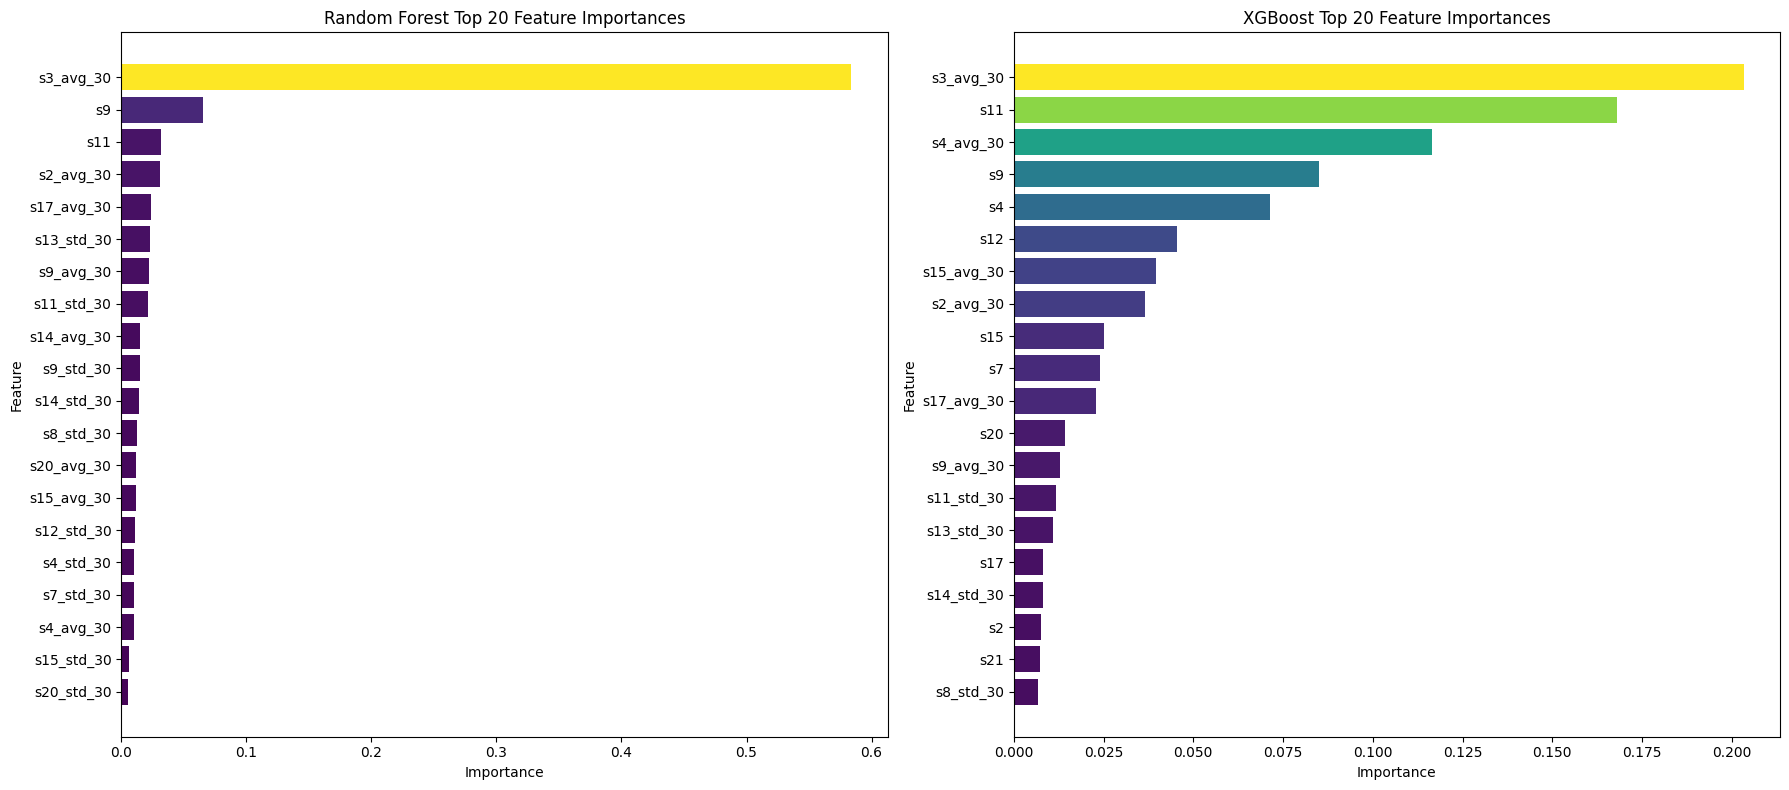

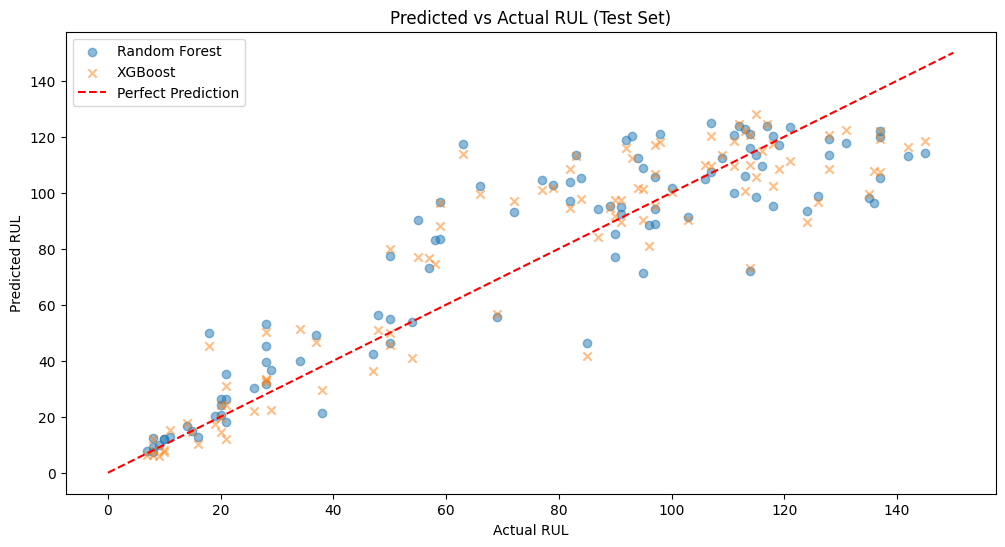

In [5]:
# Feature Importance (Both Models)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# RF Importance
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_cols).nlargest(20).sort_values(ascending=True)
colors_rf = plt.cm.viridis(rf_importances.values / rf_importances.values.max())
axes[0].barh(rf_importances.index, rf_importances.values, color=colors_rf)
axes[0].set_title("Random Forest Top 20 Feature Importances")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Feature")

# XGB Importance
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).nlargest(20).sort_values(ascending=True)
colors_xgb = plt.cm.viridis(xgb_importances.values / xgb_importances.values.max())
axes[1].barh(xgb_importances.index, xgb_importances.values, color=colors_xgb)
axes[1].set_title("XGBoost Top 20 Feature Importances")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

# Predicted vs Actual (Test Set)
plt.figure(figsize=(12, 6))
plt.scatter(y_test, rf_preds, alpha=0.5, label='Random Forest', marker='o')
plt.scatter(y_test, xgb_preds, alpha=0.5, label='XGBoost', marker='x')
plt.plot([0, 150], [0, 150], 'r--', label='Perfect Prediction')
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs Actual RUL (Test Set)")
plt.legend()
plt.show()

### Residual Analysis
Where do the models struggle (early life vs end of life)?

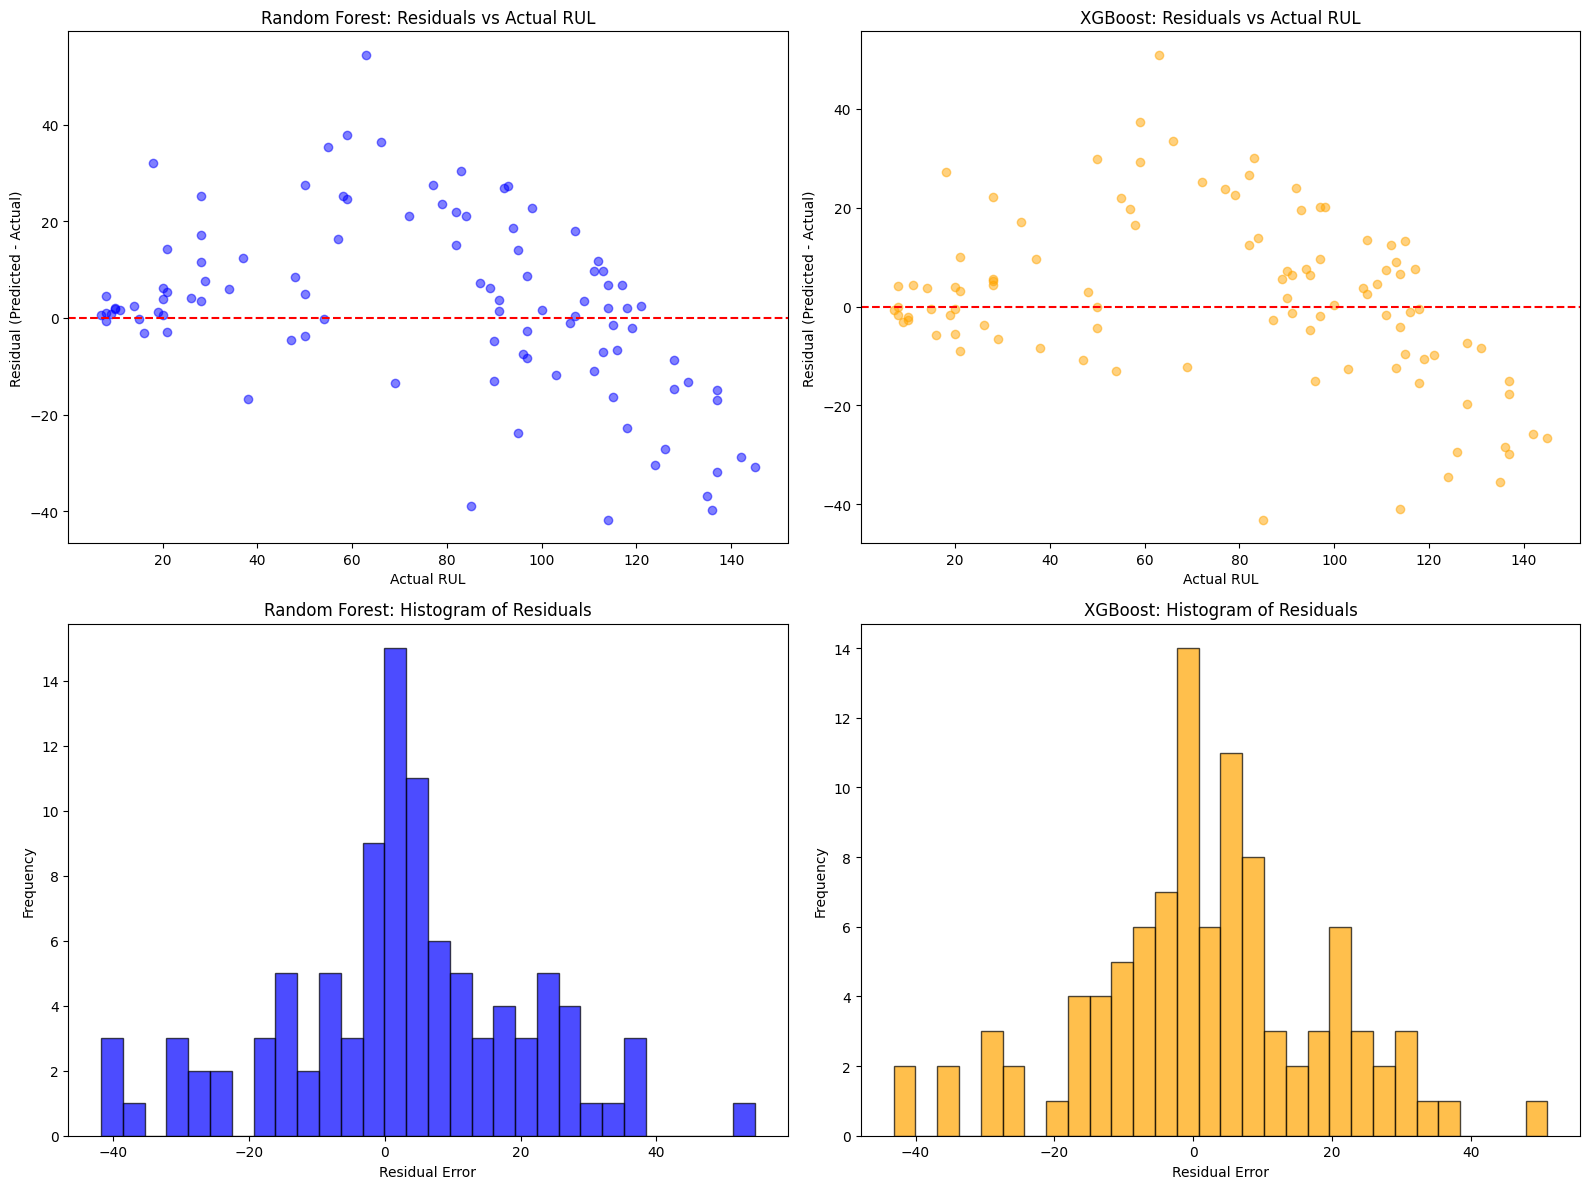

In [6]:
# Residuals = Predicted - Actual
rf_residuals = rf_preds - y_test
xgb_residuals = xgb_preds - y_test

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Residuals vs Actual RUL
axes[0, 0].scatter(y_test, rf_residuals, alpha=0.5, color='blue')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Random Forest: Residuals vs Actual RUL')
axes[0, 0].set_xlabel('Actual RUL')
axes[0, 0].set_ylabel('Residual (Predicted - Actual)')

axes[0, 1].scatter(y_test, xgb_residuals, alpha=0.5, color='orange')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('XGBoost: Residuals vs Actual RUL')
axes[0, 1].set_xlabel('Actual RUL')
axes[0, 1].set_ylabel('Residual (Predicted - Actual)')

# Histogram of Residuals
axes[1, 0].hist(rf_residuals, bins=30, edgecolor='black', color='blue', alpha=0.7)
axes[1, 0].set_title('Random Forest: Histogram of Residuals')
axes[1, 0].set_xlabel('Residual Error')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(xgb_residuals, bins=30, edgecolor='black', color='orange', alpha=0.7)
axes[1, 1].set_title('XGBoost: Histogram of Residuals')
axes[1, 1].set_xlabel('Residual Error')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Random Forest Prediction Confidence
Compute the standard deviation of predictions across all isolated trees to evaluate model uncertainty.

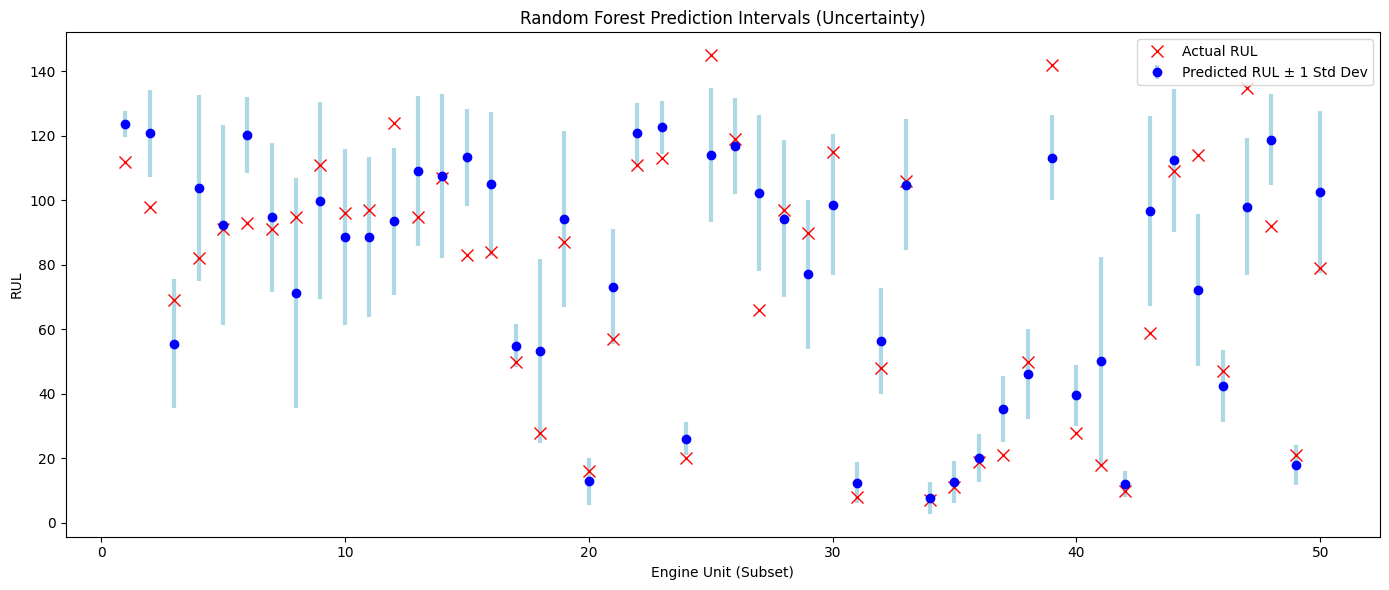

In [7]:
# Compute standard deviation of predictions across all trees in the forest
# Each tree gives a prediction, the standard deviation maps uncertainty per engine
preds_per_tree = np.array([tree.predict(X_test_last.values) for tree in rf_model.estimators_])
rf_preds_std = preds_per_tree.std(axis=0)

# Plot Error Bars for first 50 engines on the test set for readability
num_engines_to_plot = min(50, len(y_test))
engines_subset = np.arange(1, num_engines_to_plot + 1)

plt.figure(figsize=(14, 6))
plt.errorbar(engines_subset, rf_preds[:num_engines_to_plot], 
             yerr=rf_preds_std[:num_engines_to_plot], 
             fmt='o', color='blue', ecolor='lightblue', elinewidth=3, capsize=0, label='Predicted RUL ± 1 Std Dev')

plt.plot(engines_subset, y_test[:num_engines_to_plot].values, 'rx', markersize=8, label='Actual RUL')

plt.xlabel('Engine Unit (Subset)')
plt.ylabel('RUL')
plt.title('Random Forest Prediction Intervals (Uncertainty)')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Save Metrics
metrics = {
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE': [rf_rmse, xgb_rmse],
    'MAE': [rf_mae, xgb_mae],
    'NASA_Score': [rf_nasa, xgb_nasa]
}
pd.DataFrame(metrics).to_csv('../data/classical_metrics.csv', index=False)
# Save predictions for final comparison
pd.DataFrame({'Actual': y_test, 'RF': rf_preds, 'XGB': xgb_preds}).to_csv('../data/ml_preds.csv', index=False)